<a href="https://colab.research.google.com/github/Chanthul4054/Telco-Customer-Churn-Prediction/blob/main/Course_Work.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Telco Customer Churn Prediciton

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split , GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import confusion_matrix, roc_curve, auc
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score,f1_score, roc_auc_score,confusion_matrix, classification_report
from imblearn.over_sampling import SMOTE


##Load and Clean Data

In [2]:
df = pd.read_csv('/content/drive/MyDrive/Telco Dataset/Telco-Customer-Churn-dataset.csv')
print(df.shape)
df.info()
df.describe()
display(df.describe(include="all").T)

(7043, 21)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customerID,7043,7043,3186-AJIEK,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,7043,2,Male,3555,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SeniorCitizen,7043.0,NaN,NaN,NaN,0.162147,0.368612,0.0,0.0,0.0,0.0,1.0
Partner,7043,2,No,3641,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Dependents,7043,2,No,4933,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tenure,7043.0,NaN,NaN,NaN,32.371149,24.559481,0.0,9.0,29.0,55.0,72.0
PhoneService,7043,2,Yes,6361,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MultipleLines,7043,3,No,3390,NaN,NaN,NaN,NaN,NaN,NaN,NaN
InternetService,7043,3,Fiber optic,3096,NaN,NaN,NaN,NaN,NaN,NaN,NaN
OnlineSecurity,7043,3,No,3498,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors = 'coerce')
df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace = True)
if 'customerID' in df.columns:
  df.drop('customerID', axis = 1, inplace = True)
if df['Churn'].dtype == 'object':
  df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})
df.head()

/tmp/ipython-input-345066478.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace = True)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


##Exploratory Data Analysis (EDA)

Numeric Feature Distributions

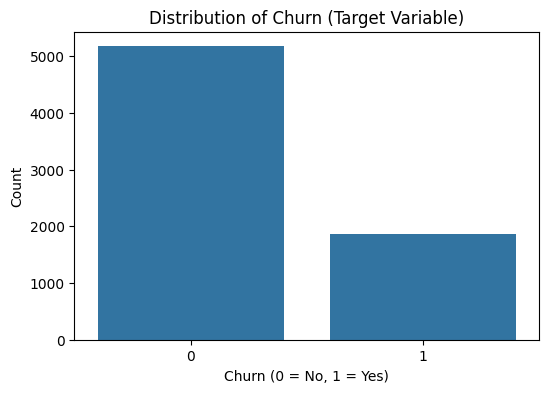

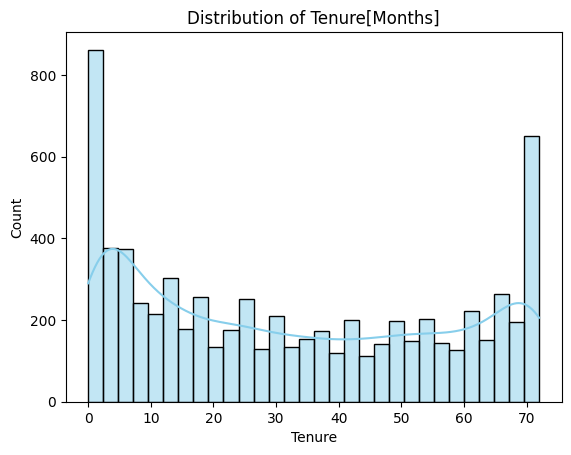

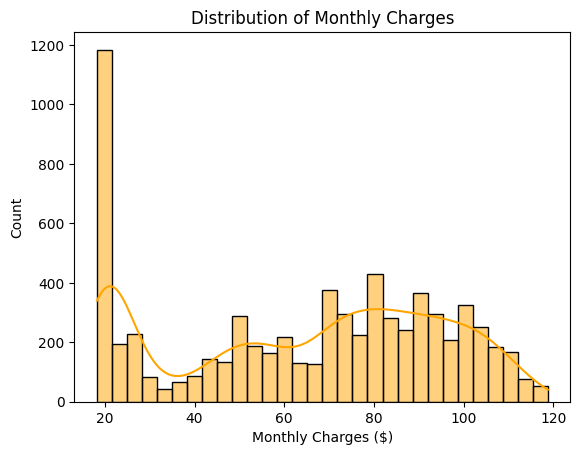

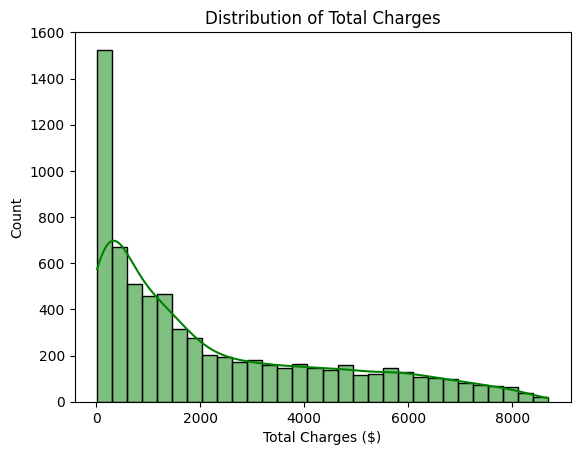

In [4]:
plt.figure(figsize=(6, 4))
sns.countplot(x='Churn', data=df)
plt.title('Distribution of Churn (Target Variable)')
plt.xlabel('Churn (0 = No, 1 = Yes)')
plt.ylabel('Count')
plt.show()

sns.histplot(df['tenure'], bins=30, kde=True , color = 'skyblue')
plt.title('Distribution of Tenure[Months]')
plt.xlabel('Tenure')
plt.show()

sns.histplot(df['MonthlyCharges'], bins= 30, kde= True, color = 'orange')
plt.title('Distribution of Monthly Charges')
plt.xlabel('Monthly Charges ($)')
plt.show()

sns.histplot(df['TotalCharges'], bins=30, kde=True, color = 'green')
plt.title('Distribution of Total Charges')
plt.xlabel('Total Charges ($)')
plt.show()

Numerical Features vs. Churn (Box Plots)

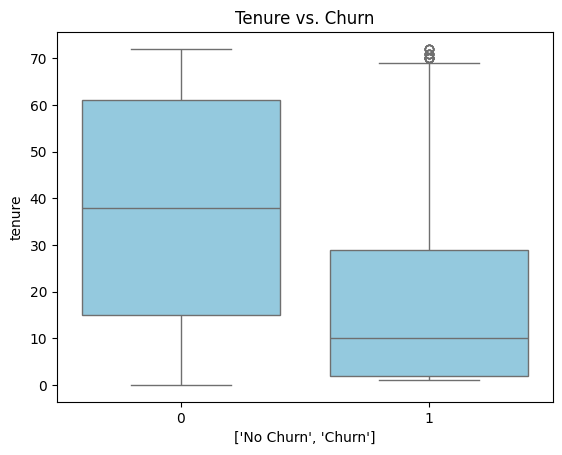

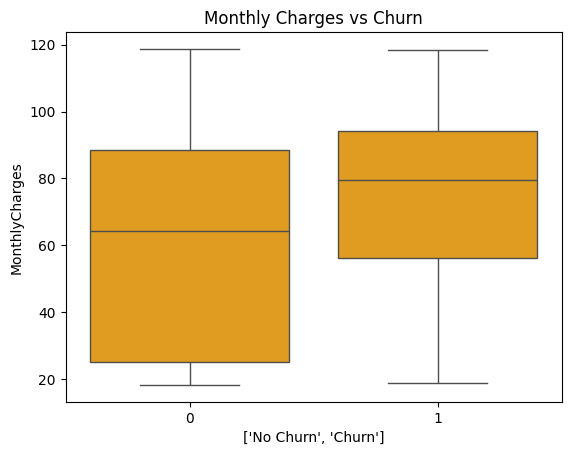

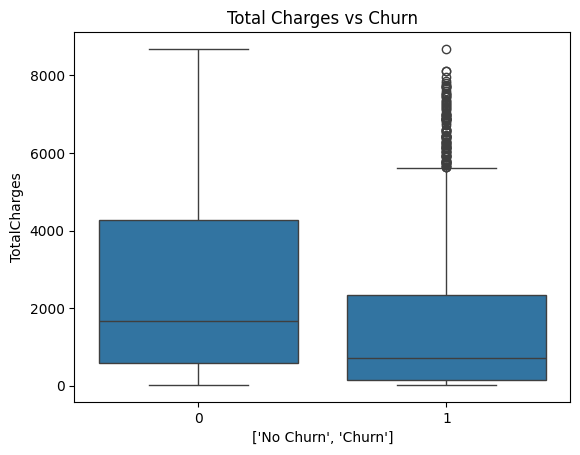

In [5]:
sns.boxplot(x='Churn', y = 'tenure', data =df ,color='skyblue')
plt.title('Tenure vs. Churn')
plt.xlabel(['No Churn' , 'Churn'])
plt.show()

sns.boxplot(x='Churn', y='MonthlyCharges', data=df , color='orange' )
plt.title('Monthly Charges vs Churn')
plt.xlabel(['No Churn', 'Churn'])
plt.show()

sns.boxplot(x='Churn', y='TotalCharges', data=df )
plt.title('Total Charges vs Churn')
plt.xlabel(['No Churn', 'Churn'])
plt.show()

Categorical Features vs. Churn

Generating plots for 16 categorical features...



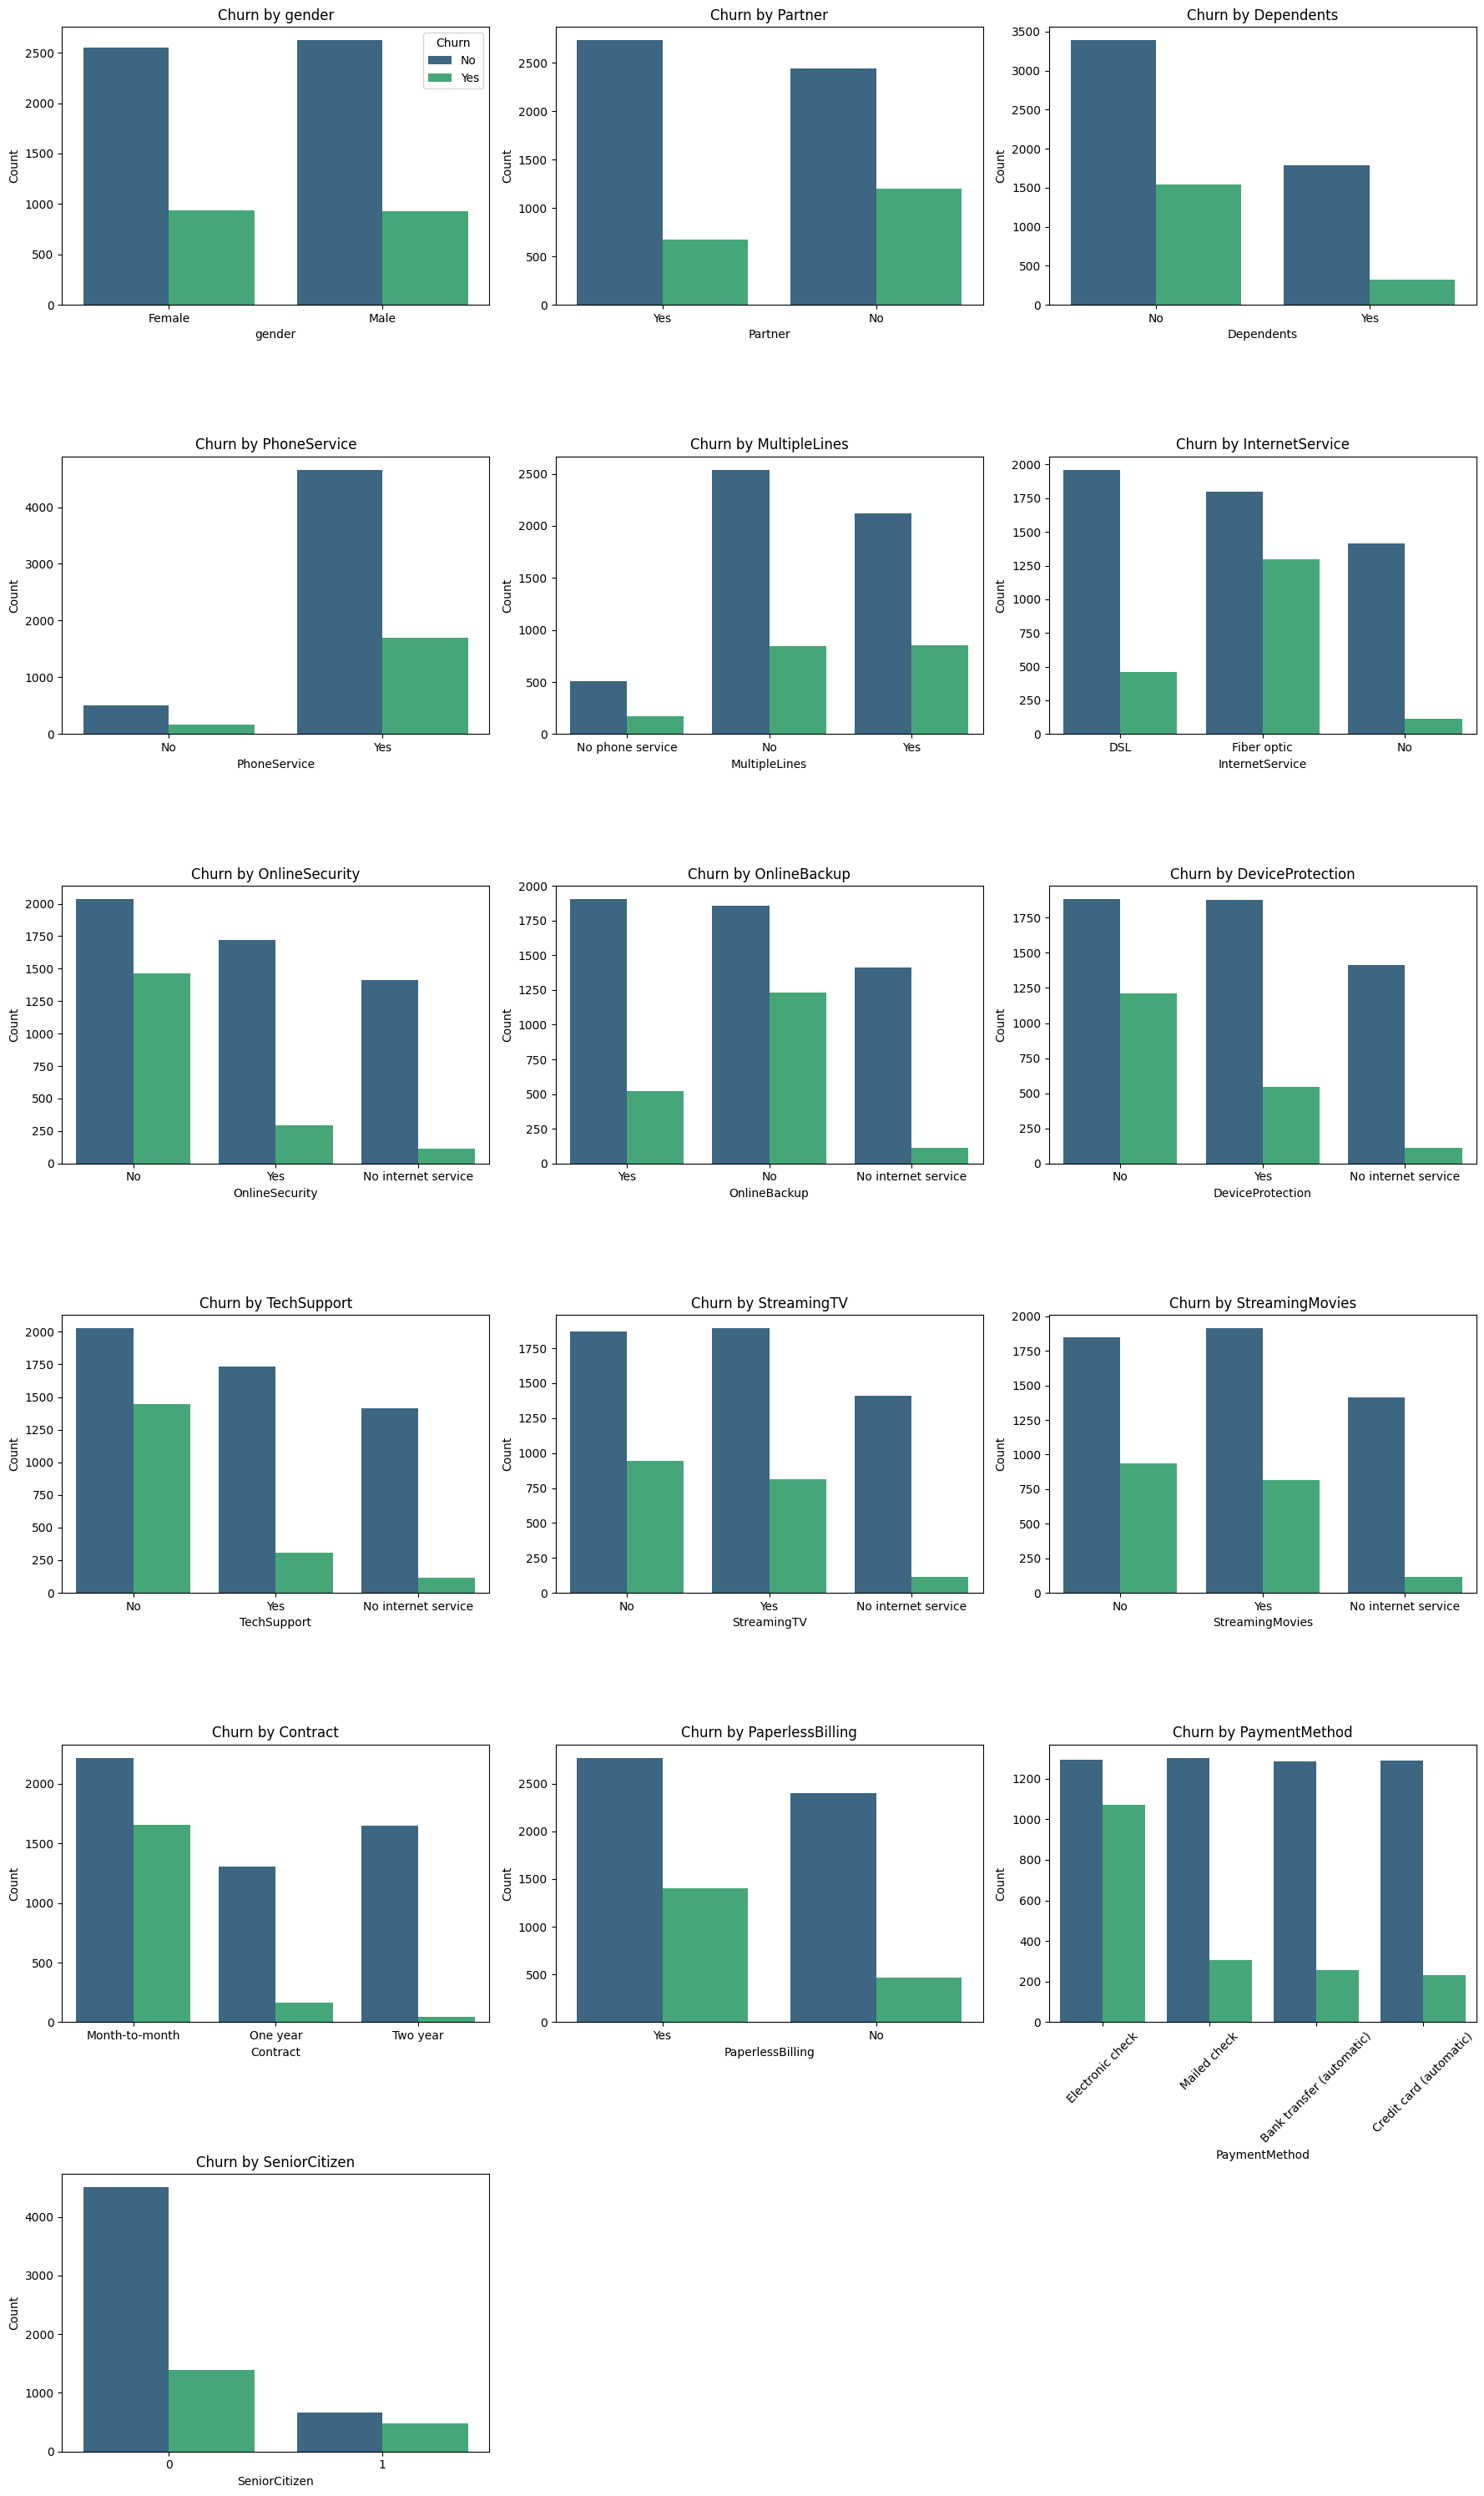

In [15]:
import math

# 1. Identify Categorical Columns
cat_cols = df.select_dtypes(include=['object']).columns.tolist()
if 'SeniorCitizen' in df.columns:
    cat_cols.append('SeniorCitizen')

cat_cols = [col for col in cat_cols if col != 'Churn' and col != 'customerID']

print(f"Generating plots for {len(cat_cols)} categorical features...\n")

n_cols = 3
n_rows = math.ceil(len(cat_cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 5))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    sns.countplot(x=col, hue='Churn', data=df, ax=axes[i], palette='viridis')
    axes[i].set_title(f'Churn by {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')

    if df[col].nunique() > 3:
        axes[i].tick_params(axis='x', rotation=45)

    if i == 0:
        axes[i].legend(title='Churn', loc='upper right', labels=['No', 'Yes'])
    else:
        axes[i].get_legend().remove()

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

#Data Preprocessing

In [7]:
#Separate Features
x = df.drop('Churn', axis = 1)
y = df['Churn']
x = pd.get_dummies(x, drop_first = True)

# Train-test split
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.2 , random_state=42 , stratify=y )

#scaling
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

print("Original Training Class Distribution:\n", y_train.value_counts())

smote= SMOTE(random_state=42)
x_train_smote, y_train_smote = smote.fit_resample(x_train_scaled, y_train)

print("\nSMOTE Applied. New Training Class Distribution:\n", y_train_smote.value_counts())
print(f"\nTraining set shape (after SMOTE): {x_train_smote.shape}")
print(f"Test set shape (original): {x_test_scaled.shape}")

Original Training Class Distribution:
 Churn
0    4139
1    1495
Name: count, dtype: int64

SMOTE Applied. New Training Class Distribution:
 Churn
0    4139
1    4139
Name: count, dtype: int64

Training set shape (after SMOTE): (8278, 30)
Test set shape (original): (1409, 30)


#Decision Tree Model

In [8]:
dt = DecisionTreeClassifier(random_state=42)

param_grid = {
    'max_depth': [3, 5, 10, None],
    'min_samples_split': [2, 5, 10],
    'criterion': ['gini', 'entropy']
}

grid_search = GridSearchCV(dt, param_grid, cv=5, scoring='accuracy')
grid_search.fit(x_train_smote, y_train_smote)

best_dt = grid_search.best_estimator_

y_pred = best_dt.predict(x_test_scaled)

print(f"Best DT Params: {grid_search.best_params_}")
print("\n--- Decision Tree Classification Report ---")
print(classification_report(y_test, y_pred))

dt_roc_auc = roc_auc_score(y_test, best_dt.predict_proba(x_test_scaled)[:, 1])
print(f"Decision Tree ROC AUC Score: {dt_roc_auc}")



Best DT Params: {'criterion': 'gini', 'max_depth': 10, 'min_samples_split': 10}

--- Decision Tree Classification Report ---
              precision    recall  f1-score   support

           0       0.86      0.76      0.81      1035
           1       0.50      0.66      0.57       374

    accuracy                           0.73      1409
   macro avg       0.68      0.71      0.69      1409
weighted avg       0.76      0.73      0.74      1409

Decision Tree ROC AUC Score: 0.7865380144152523


#Neural Network Model

In [9]:
!pip install keras-tuner

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 6.5 MB/s eta 0:00:00


Trial 30 Complete [00h 00m 21s]
val_accuracy: 0.7288857102394104

Best val_accuracy So Far: 0.7721788287162781
Total elapsed time: 00h 05m 29s

The hyperparameter search is complete.
The optimal number of units in the first hidden layer is 64.
The optimal dropout rate is 0.4.
The optimal learning rate for the optimizer is 0.001.


--- Training Best Model ---
Epoch 1/20
233/233 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.6512 - loss: 0.6293 - val_accuracy: 0.7367 - val_loss: 0.6062
Epoch 2/20
233/233 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7582 - loss: 0.5005 - val_accuracy: 0.7693 - val_loss: 0.5255
Epoch 3/20
233/233 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7720 - loss: 0.4729 - val_accuracy: 0.7536 - val_loss: 0.5416
Epoch 4/20
233/233 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7611 - loss: 0.4823 - val_accuracy: 0.7464 - val_loss: 0.5346
Epoch 5/20
233/233 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7787 - loss: 0.4653 - val_accuracy: 0.7415 - val_loss: 0.537

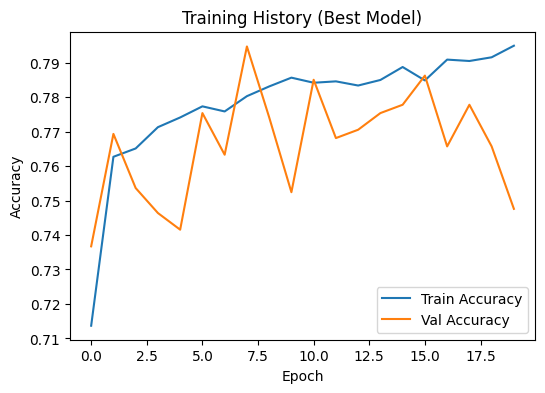

In [10]:
import keras_tuner as kt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

def build_model(hp):
    model = keras.Sequential()

    model.add(layers.Input(shape=(x_train_smote.shape[1],)))

    hp_units = hp.Int('units', min_value=16, max_value=64, step=16)
    model.add(layers.Dense(units=hp_units, activation='relu'))

    hp_dropout = hp.Float('dropout', min_value=0.1, max_value=0.4, step=0.1)
    model.add(layers.Dropout(rate=hp_dropout))

    model.add(layers.Dense(16, activation='relu'))

    model.add(layers.Dense(1, activation='sigmoid'))

    hp_learning_rate = hp.Choice('learning_rate', values=[1e-2, 1e-3, 1e-4])

    model.compile(optimizer=keras.optimizers.Adam(learning_rate=hp_learning_rate),
                  loss='binary_crossentropy',
                  metrics=['accuracy'])
    return model

tuner = kt.Hyperband(build_model,
                     objective='val_accuracy',
                     max_epochs=20,
                     factor=3,
                     directory='my_dir',
                     project_name='intro_to_kt',
                     overwrite=True)

tuner.search(x_train_smote, y_train_smote, epochs=15, validation_data=(x_test_scaled, y_test))

# Get the Best Hyperparameters
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]

print(f"""
The hyperparameter search is complete.
The optimal number of units in the first hidden layer is {best_hps.get('units')}.
The optimal dropout rate is {best_hps.get('dropout')}.
The optimal learning rate for the optimizer is {best_hps.get('learning_rate')}.
""")

#  Build and Train the Best Model
print("\n--- Training Best Model ---")
best_model = tuner.hypermodel.build(best_hps)
history = best_model.fit(x_train_smote, y_train_smote,
                         epochs=20,
                         batch_size=32,
                         validation_split=0.1,
                         verbose=1)

# 6. Evaluation
print("\n--- Neural Network Evaluation (Tuned) ---")
y_pred_nn_prob = best_model.predict(x_test_scaled)
y_pred_nn = (y_pred_nn_prob > 0.5).astype("int32")

print(classification_report(y_test, y_pred_nn))
print(f"Neural Network ROC-AUC Score: {roc_auc_score(y_test, y_pred_nn_prob):.4f}")

# Plot History
plt.figure(figsize=(6, 4))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label = 'Val Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.title('Training History (Best Model)')
plt.show()

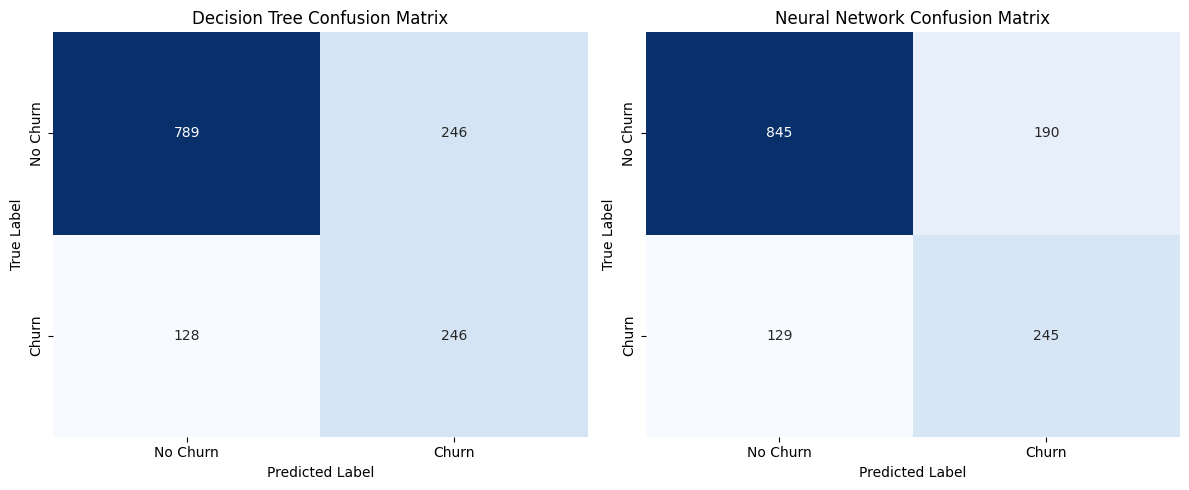

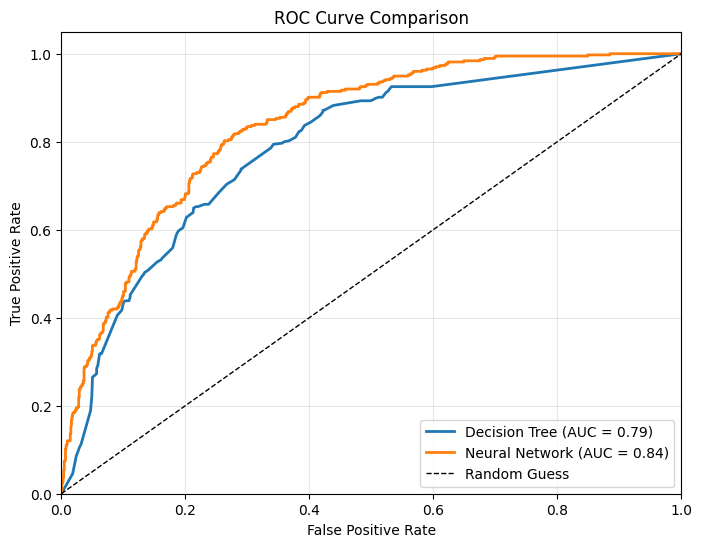

In [14]:
# --- Confusion Matrix Heatmaps ---
def plot_confusion_matrix(y_true, y_pred, title, ax):
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, cbar=False)
    ax.set_title(title)
    ax.set_xlabel('Predicted Label')
    ax.set_ylabel('True Label')
    ax.set_xticklabels(['No Churn', 'Churn'])
    ax.set_yticklabels(['No Churn', 'Churn'])

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot Decision Tree Confusion Matrix
plot_confusion_matrix(y_test, y_pred, "Decision Tree Confusion Matrix", axes[0])

# Plot Neural Network Confusion Matrix
plot_confusion_matrix(y_test, y_pred_nn, "Neural Network Confusion Matrix", axes[1])

plt.tight_layout()
plt.show()

# --- ROC Curve Comparison ---
plt.figure(figsize=(8, 6))

# Decision Tree ROC
y_prob_dt = best_dt.predict_proba(x_test_scaled)[:, 1]
fpr_dt, tpr_dt, _ = roc_curve(y_test, y_prob_dt)
roc_auc_dt = auc(fpr_dt, tpr_dt)
plt.plot(fpr_dt, tpr_dt, label=f'Decision Tree (AUC = {roc_auc_dt:.2f})', linewidth=2)

# Neural Network ROC
fpr_nn, tpr_nn, _ = roc_curve(y_test, y_pred_nn_prob)
roc_auc_nn = auc(fpr_nn, tpr_nn)
plt.plot(fpr_nn, tpr_nn, label=f'Neural Network (AUC = {roc_auc_nn:.2f})', linewidth=2)

# Plot "Random Guess" line
plt.plot([0, 1], [0, 1], 'k--', lw=1, label='Random Guess')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

#Comparison of Results

In [16]:
dt_acc = accuracy_score(y_test, y_pred)
nn_acc = accuracy_score(y_test, y_pred_nn)

print("--- Final Model Comparison ---")
print(f"Decision Tree Accuracy: {dt_acc}")
print(f"Neural Network Accuracy: {nn_acc}")

if nn_acc > dt_acc:
    print("Conclusion: The Neural Network performed better.")
else:
    print("Conclusion: The Decision Tree performed better.")



--- Final Model Comparison ---
Decision Tree Accuracy: 0.7345635202271115
Neural Network Accuracy: 0.7735982966643009
Conclusion: The Neural Network performed better.
